# ECLIPSE — Part III: Clustering and Prioritization

This notebook takes the two output CSVs from Part II directly as input.
No Atlas files needed — all filtering and species proportion calculation
was already done in Part II.

### Workflow
```
eclipse_search_results_component_dark_genus_specific.csv
eclipse_search_results_component_dark_eskape_enriched.csv
          |
1. Length filter >= 300 aa on both tracks
          |
2. Export FASTA per track
          |
3. MMseqs2 easy-cluster on both tracks
          |
4. Select one representative per cluster
          |
5. DPPS scoring
          |
6. Monte Carlo weight sensitivity analysis (n=500)
          |
7. Ranked output tables + figures
```

### Input files (outputs from Part II)
| File | Description |
|------|-------------|
| `PS_CSV` (set in config below) | Genus-specific track |
| `ES_CSV` (set in config below) | ESKAPE-enriched track |

### DPPS formula

| Sub-score | Definition | Track A weight | Track B weight |
|-----------|-----------|----------------|----------------|
| S1 darkness | 1 - (brightness / 100) — flat 1.0 for all dark components | 0.15 | 0.15 |
| S2b combined species evidence | max(Atlas species proportion, query strain fraction) — **Track A only** | 0.40 | — |
| S2 species proportion | Fraction of Atlas members annotated as target species — **Track B only** | — | 0.25 |
| S3 taxonomic specificity | 1 - ESKAPE_relative_evenness | 0.25 | 0.20 |
| S4 strain coverage | Unique strains carrying component / total strains (from queryID_to_strain.csv) | 0.20 | 0.15 |
| S5 ESKAPE enrichment | ESKAPE_proportion x (1 - ESKAPE_genus_evenness) — **Track B only** | — | 0.25 |

**Why S2b for Track A?**
Genus-specific components can show low Atlas species proportion despite near-universal
conservation in the query strain collection, due to non-canonical species annotation
in UniProt (e.g. 'Pseudomonas sp.' instead of 'Pseudomonas aeruginosa').
S2b corrects for this by taking the maximum of the Atlas-derived proportion and the
query-level strain fraction, ensuring genuine target-species components are not
penalised by annotation gaps.

**Tiers:** I (DPPS >= 0.75) · II (0.50-0.75) · III (0.25-0.50) · IV (< 0.25)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import subprocess
import math
import os
import re
import warnings
warnings.filterwarnings('ignore')

# ==========================================================================
# UNIVERSAL PATHOGEN CONFIG - change only this block for each new pathogen
# ==========================================================================
GENUS        = "Pseudomonas"           # genus used in Part II genus-specific filter
SPECIES      = "Pseudomonas aeruginosa"# species string used in Atlas proportion column
SPECIES_COL  = "p_aeruginosa_proportion" # column name as it appears in Part II CSVs
SPECIES_ABBR = "PA"                    # short label for plot axes and print statements
FAA_DIR      = "./faa"                 # folder of downloaded .faa files (for N_STRAINS)

#  Input files (Part II outputs) - filenames unchanged
PS_CSV = './mapped_p_aer_dataset_pseudomonas_specific_dark_components.csv'
ES_CSV = './mapped_p_aer_dataset_eskape_enriched_dark_components.csv'
# ==========================================================================

#  Filtering
MIN_SEQ_LEN = 300

# Auto-count strains from your downloaded .faa directory
# Each unique GCF/GCA accession = one strain. Falls back to filename stem.
_accession_re = re.compile(r'(GC[FA]_\d+\.\d+)', re.IGNORECASE)

def _strain_from_filename(fname):
    m = _accession_re.search(fname)
    if m:
        return m.group(1)
    for ext in ('.faa', '.fasta', '.fa', '.fna'):
        if fname.lower().endswith(ext):
            fname = fname[:-len(ext)]
            break
    return fname

def count_strains(faa_dir):
    if not os.path.isdir(faa_dir):
        raise FileNotFoundError(
            f"FAA directory not found: {faa_dir}\n"
            "Set FAA_DIR to your folder of downloaded .faa files."
        )
    files = [f for f in os.listdir(faa_dir)
             if os.path.isfile(os.path.join(faa_dir, f))
             and f.lower().endswith(('.faa', '.fasta', '.fa', '.fna'))
             and not f.startswith('.')]
    strains = {_strain_from_filename(f) for f in files}
    print(f"FAA directory    : {faa_dir}")
    print(f"Total .faa files : {len(files)}")
    print(f"Unique strains   : {len(strains)}")
    if len(files) != len(strains):
        print(f"  NOTE: file count differs from strain count")
        print(f"  (multi-file assemblies detected - using strain count)")
    return len(strains)

N_STRAINS = count_strains(FAA_DIR)

#  MMseqs2 clustering parameters
MMSEQS_MIN_SEQ_ID = 0.3
MMSEQS_COVERAGE   = 0.8
MMSEQS_TMP        = './tmp_mmseqs'

#  DPPS weights - genus-specific track (Track A)
# S2b replaces S2 for Track A.
# Genus-specific components can show suppressed Atlas species proportion due to
# non-canonical annotation in UniProt (e.g. 'Pseudomonas sp.').
# S2b = max(Atlas species proportion, query strain fraction) corrects for this.
WEIGHTS_PS = {
    'S1_darkness':           0.15,
    'S2b_pa_combined':       0.40,
    'S3_specificity':        0.25,
    'S4_pa_strain_coverage': 0.20,
}
assert abs(sum(WEIGHTS_PS.values()) - 1.0) < 1e-9, 'WEIGHTS_PS must sum to 1.0'

# DPPS weights - ESKAPE-enriched track (Track B)
# Track B uses standard S2 (Atlas species proportion) because ESKAPE-enriched
# components span multiple genera and Atlas annotation is more reliable
# at the ESKAPE level than at the species level.
WEIGHTS_ES = {
    'S1_darkness':           0.15,
    'S2_pa_proportion':      0.25,
    'S3_specificity':        0.20,
    'S4_pa_strain_coverage': 0.15,
    'S5_eskape_enrich':      0.25,
}
assert abs(sum(WEIGHTS_ES.values()) - 1.0) < 1e-9, 'WEIGHTS_ES must sum to 1.0'

# Tier boundaries
TIER_BINS   = [0, 0.25, 0.50, 0.75, 1.01]
TIER_LABELS = ['IV', 'III', 'II', 'I']
TIER_COLORS = {'I': '#7B2D8B', 'II': '#D85A30', 'III': '#1D9E75', 'IV': '#888780'}

os.makedirs(MMSEQS_TMP, exist_ok=True)
print()
print('Configuration loaded.')
print(f'  Genus            : {GENUS}')
print(f'  Species          : {SPECIES}')
print(f'  Species column   : {SPECIES_COL}')
print(f'  Genus-specific input : {PS_CSV}')
print(f'  ESKAPE-enriched input: {ES_CSV}')
print(f'  Min sequence length  : {MIN_SEQ_LEN} aa')
print(f'  Total strains        : {N_STRAINS}')
print(f'  MMseqs2: min-seq-id={MMSEQS_MIN_SEQ_ID}, coverage={MMSEQS_COVERAGE}')
print()
print('Track A weights (S2b = combined species evidence):')
for k, v in WEIGHTS_PS.items():
    print(f'  {k}: {v}')
print('Track B weights:')
for k, v in WEIGHTS_ES.items():
    print(f'  {k}: {v}')


FAA directory    : ./faa
Total .faa files : 635
Unique strains   : 635

Configuration loaded.
  Genus            : Pseudomonas
  Species          : Pseudomonas aeruginosa
  Species column   : p_aeruginosa_proportion
  Genus-specific input : ./mapped_p_aer_dataset_pseudomonas_specific_dark_components.csv
  ESKAPE-enriched input: ./mapped_p_aer_dataset_eskape_enriched_dark_components.csv
  Min sequence length  : 300 aa
  Total strains        : 635
  MMseqs2: min-seq-id=0.3, coverage=0.8

Track A weights (S2b = combined species evidence):
  S1_darkness: 0.15
  S2b_pa_combined: 0.4
  S3_specificity: 0.25
  S4_pa_strain_coverage: 0.2
Track B weights:
  S1_darkness: 0.15
  S2_pa_proportion: 0.25
  S3_specificity: 0.2
  S4_pa_strain_coverage: 0.15
  S5_eskape_enrich: 0.25


---
## 1. Load Part II outputs

In [2]:
df_ps = pd.read_csv(PS_CSV)
df_es = pd.read_csv(ES_CSV)

print(f'Genus-specific  : {len(df_ps):,} proteins, '
      f'{df_ps["componentID"].nunique():,} components')
print(f'ESKAPE-enriched : {len(df_es):,} proteins, '
      f'{df_es["componentID"].nunique():,} components')
print(f'\nColumns: {list(df_ps.columns)}')


Genus-specific  : 13,230 proteins, 83 components
ESKAPE-enriched : 39,452 proteins, 215 components

Columns: ['queryID', 'SEQ', 'targetID', 'fident', 'alnlen', 'mismatch', 'gapopen', 'qstart', 'qend', 'tstart', 'tend', 'eVal', 'bits', 'communityID', 'brightness', 'componentID', 'component_brightness', 'ESKAPE_relative_evenness', 'ESKAPE_genus_evenness', 'ESKAPE_proportion', 'p_aeruginosa_proportion']


---
## 2. Length filter >= 300 aa on both tracks

Pseudomonas-specific:
  Before: 13,230 proteins, 83 components
  Dropped: 70 components (median seq len < 300 aa)
  Dropped: 11,759 proteins from those components
  Retained: 1,471 proteins, 13 components
  Dropped component median lengths:
 componentID  median_seq_len
      107877            46.0
       51064            65.0
      168893            65.0
      158399            65.5
       79969            67.0
      129813            75.0
      118183            80.0
       61895            84.0
       33561            85.0
      184475            86.0
      194242            88.0
       92485            89.0
       23464            91.0
      118432            92.0
      130808            92.0
       67756            99.0
      123371           107.0
      112954           107.0
      114039           112.0
      132142           112.0
      159458           115.0
       67761           117.0
      109482           117.0
      115331           118.0
      148005           118.0
     

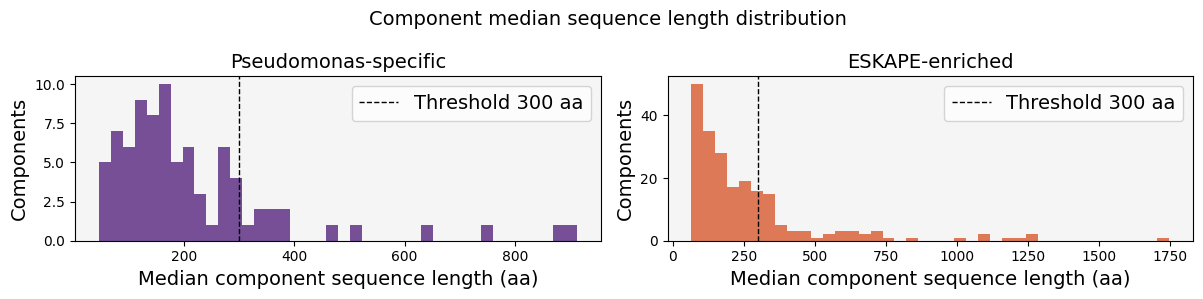

Saved: seq_len_both_tracks.pdf


In [3]:
def apply_length_filter(df_in, track_name, min_len=MIN_SEQ_LEN):
    """
    Filter by MEDIAN component sequence length, not individual protein length.
    This correctly handles components like 103202 where 623/626 proteins are
    265 aa but 3 outlier proteins are 304-340 aa - the component should be
    excluded based on its representative (median) length, not the outliers.
    """
    df_out = df_in.copy()
    df_out['seq_len'] = df_out['SEQ'].str.len()

    # Compute median sequence length per component
    comp_median_len = (
        df_out.groupby('componentID')['seq_len']
        .median()
        .reset_index(name='median_seq_len')
    )

    # Identify components where median length >= threshold
    valid_comps = comp_median_len.loc[
        comp_median_len['median_seq_len'] >= min_len, 'componentID'
    ].tolist()

    n_comps_before = df_out['componentID'].nunique()
    n_prots_before = len(df_out)

    # Keep ALL proteins from valid components
    df_out = df_out[df_out['componentID'].isin(valid_comps)].copy()

    n_comps_dropped = n_comps_before - df_out['componentID'].nunique()
    n_prots_dropped = n_prots_before - len(df_out)

    print(f'{track_name}:')
    print(f'  Before: {n_prots_before:,} proteins, {n_comps_before:,} components')
    print(f'  Dropped: {n_comps_dropped:,} components (median seq len < {min_len} aa)')
    print(f'  Dropped: {n_prots_dropped:,} proteins from those components')
    print(f'  Retained: {len(df_out):,} proteins, '
          f'{df_out["componentID"].nunique():,} components')

    # Show dropped components and their median lengths for transparency
    dropped = comp_median_len[~comp_median_len['componentID'].isin(valid_comps)]
    if len(dropped) > 0:
        print(f'  Dropped component median lengths:')
        print(dropped.sort_values('median_seq_len').to_string(index=False))

    return df_out

df_ps_filt = apply_length_filter(df_ps, f'{GENUS}-specific')
print()
df_es_filt = apply_length_filter(df_es, 'ESKAPE-enriched')

# Length distribution plots - show median seq len per component
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
for ax, df_in, title, color in zip(
        axes,
        [df_ps, df_es],
        [f'{GENUS}-specific', 'ESKAPE-enriched'],
        ['#57257F', '#D85A30']):
    df_in = df_in.copy()
    df_in['seq_len'] = df_in['SEQ'].str.len()
    median_lens = df_in.groupby('componentID')['seq_len'].median()
    ax.hist(median_lens, bins=40, color=color, alpha=0.8, edgecolor='none')
    ax.axvline(MIN_SEQ_LEN, color='black', linewidth=1, linestyle='--',
               label=f'Threshold {MIN_SEQ_LEN} aa')
    ax.set_xlabel('Median component sequence length (aa)', fontsize=14)
    ax.set_ylabel('Components', fontsize=14)
    ax.set_title(title, fontsize=14)
    ax.legend(fontsize=14)
    ax.set_facecolor('#F5F5F5')
fig.suptitle('Component median sequence length distribution', fontsize=14)
fig.tight_layout()
plt.savefig('./seq_len_both_tracks.pdf', bbox_inches='tight', dpi=300)
plt.show()
print('Saved: seq_len_both_tracks.pdf')


---
## 3. Export FASTA files

In [4]:
def write_fasta(df_in, fasta_path):
    df_unique = df_in.drop_duplicates(subset='queryID')
    with open(fasta_path, 'w') as fh:
        for _, row in df_unique.iterrows():
            fh.write(f'>{row["queryID"]}\n{row["SEQ"]}\n')
    print(f'Written {len(df_unique):,} sequences -> {fasta_path}')

write_fasta(df_ps_filt, './track_ps_pseudomonas_specific.fasta')
write_fasta(df_es_filt, './track_es_eskape_enriched.fasta')

Written 1,471 sequences -> ./track_ps_pseudomonas_specific.fasta
Written 15,078 sequences -> ./track_es_eskape_enriched.fasta


---
## 4. MMseqs2 easy-cluster

Groups similar sequences into clusters — replacing the manual CLANS step.
Adjust `MMSEQS_MIN_SEQ_ID` and `MMSEQS_COVERAGE` in Section 0 to match
the parameters you used manually.

In [5]:
def run_mmseqs_cluster(fasta_in, prefix, tmp_dir, min_seq_id, coverage):
    cluster_tsv = f'{prefix}_cluster.tsv'
    cmd = [
        'mmseqs', 'easy-cluster',
        fasta_in, prefix, tmp_dir,
        '--min-seq-id', str(min_seq_id),
        '-c',           str(coverage),
        '--cov-mode',   '0',
        '-v',           '1'
    ]
    print(f'Running: {" ".join(cmd)}')
    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.returncode != 0:
        print('MMseqs2 stderr:')
        print(result.stderr[-1000:])
        return None
    print(result.stdout[-500:] if len(result.stdout) > 500 else result.stdout)
    return cluster_tsv

tsv_ps = run_mmseqs_cluster(
    './track_ps_pseudomonas_specific.fasta',
    './cluster_ps', MMSEQS_TMP, MMSEQS_MIN_SEQ_ID, MMSEQS_COVERAGE
)
print()
tsv_es = run_mmseqs_cluster(
    './track_es_eskape_enriched.fasta',
    './cluster_es', MMSEQS_TMP, MMSEQS_MIN_SEQ_ID, MMSEQS_COVERAGE
)

Running: mmseqs easy-cluster ./track_ps_pseudomonas_specific.fasta ./cluster_ps ./tmp_mmseqs --min-seq-id 0.3 -c 0.8 --cov-mode 0 -v 1


Running: mmseqs easy-cluster ./track_es_eskape_enriched.fasta ./cluster_es ./tmp_mmseqs --min-seq-id 0.3 -c 0.8 --cov-mode 0 -v 1



---
## 5. Select one representative per cluster

MMseqs2 picks one representative per cluster automatically.
Cluster size is recorded — a representative standing for a large cluster
means that sequence pattern is widely conserved across your dataset.

In [6]:
def parse_clusters(cluster_tsv, df_filtered, track_name):
    """
    Parse MMseqs2 cluster TSV (col0=representative, col1=member).
    Returns dataframe of representative proteins with cluster_size column.
    """
    clusters = pd.read_csv(cluster_tsv, sep='\t', header=None,
                           names=['representative', 'member'])

    # Count members per representative = cluster size
    cluster_sizes = (
        clusters.groupby('representative')
        .size()
        .reset_index(name='cluster_size')
    )

    # Select representative rows from filtered protein table
    reps = df_filtered.loc[
        df_filtered['queryID'].isin(cluster_sizes['representative'])
    ].drop_duplicates(subset='queryID').copy()

    reps = reps.merge(
        cluster_sizes, left_on='queryID', right_on='representative', how='left'
    )
    reps['cluster_size'] = reps['cluster_size'].fillna(1).astype(int)

    print(f'{track_name}:')
    print(f'  Proteins after length filter: {len(df_filtered):,}')
    print(f'  Clusters formed:              {len(cluster_sizes):,}')
    print(f'  Representatives selected:     {len(reps):,}')
    print(f'  Redundant sequences removed:  {len(df_filtered) - len(reps):,}')
    print(f'  Cluster size - mean: {reps["cluster_size"].mean():.1f}, '
          f'max: {reps["cluster_size"].max()}')
    return reps

print(f'{GENUS}-specific:')
reps_ps = parse_clusters(tsv_ps, df_ps_filt, f'{GENUS}-specific')
print()
print('ESKAPE-enriched:')
reps_es = parse_clusters(tsv_es, df_es_filt, 'ESKAPE-enriched')

Pseudomonas-specific:
Pseudomonas-specific:
  Proteins after length filter: 1,471
  Clusters formed:              20
  Representatives selected:     20
  Redundant sequences removed:  1,451
  Cluster size - mean: 73.5, max: 676

ESKAPE-enriched:
ESKAPE-enriched:
  Proteins after length filter: 15,078
  Clusters formed:              102
  Representatives selected:     102
  Redundant sequences removed:  14,976
  Cluster size - mean: 147.8, max: 1931


---
## 6. Build component-level tables

Scoring happens at component level. Cluster size is aggregated per component
as the maximum cluster size among all representatives in that component —
the largest cluster within a component is the most informative signal.

In [7]:
# COMP_COLS uses SPECIES_COL from config -- works for any pathogen
COMP_COLS = ['componentID', 'component_brightness', 'ESKAPE_proportion',
             'ESKAPE_genus_evenness', 'ESKAPE_relative_evenness',
             SPECIES_COL]

# -- Universal strain counting ----------------------------------------------
# Two queryID formats exist across ESKAPE datasets:
#
#   Format A -- custom prefix (P. aeruginosa, custom-named FASTAs):
#     PAO1_PA0001, A0K_RS05590 -- strain = everything before first underscore
#     This is the published P. aeruginosa method. Reproducible and correct.
#
#   Format B -- NCBI protein accessions (S. aureus, K. pneumoniae, etc.):
#     ABD20461.1, WP_000123.1 -- NO strain info in queryID at all
#     Must use queryID_to_strain.csv built from filenames in Part I.
#
# Detection: if >50% of queryIDs contain an underscore AND the part before
# the first underscore is short (<=10 chars, i.e. a strain prefix not an
# accession prefix like WP or NP), use Format A. Otherwise use Format B.

def _detect_queryid_format(df):
    sample = df['queryID'].dropna().head(200)
    has_underscore = sample.str.contains('_', regex=False)
    if has_underscore.mean() < 0.5:
        return 'accession'   # Format B -- no underscores, NCBI accessions
    prefix_len = sample[has_underscore].str.split('_').str[0].str.len()
    if prefix_len.median() <= 10:
        return 'prefix'      # Format A -- short prefix = strain name
    return 'accession'       # Format B -- long prefix = accession fragment

_fmt = _detect_queryid_format(pd.concat([df_ps_filt, df_es_filt]))
print(f"QueryID format detected: '{_fmt}'")

if _fmt == 'prefix':
    # Format A: extract strain from queryID directly (published P. aeruginosa method)
    print("Using queryID prefix method (strain = text before first underscore)")
    _strain_map = None
else:
    # Format B: load filename-based mapping from Part I
    print("Using queryID_to_strain.csv (strain from .faa filename)")
    _strain_map_path = './queryID_to_strain.csv'
    if not os.path.exists(_strain_map_path):
        raise FileNotFoundError(
            f"Cannot find {_strain_map_path}\n"
            "Re-run the updated Cell 40 in Part I to generate it."
        )
    _strain_map = pd.read_csv(_strain_map_path)
    print(f"Strain map loaded: {len(_strain_map):,} proteins, "
          f"{_strain_map['strain'].nunique():,} unique strains")

def build_component_table(df_filtered, track_name):
    # One row per component
    comp = df_filtered[COMP_COLS].drop_duplicates(subset='componentID').copy()

    df_copy = df_filtered[['queryID', 'componentID']].copy()

    if _fmt == 'prefix':
        # Format A -- published method: split queryID on underscore, take first part
        has_underscore = df_copy['queryID'].str.contains('_', regex=False)
        n_malformed = (~has_underscore).sum()
        if n_malformed > 0:
            print(f'Warning: {n_malformed} queryIDs have no underscore and are excluded')
        df_copy = df_copy[has_underscore].copy()
        df_copy['strain'] = df_copy['queryID'].str.split('_').str[0]
    else:
        # Format B -- filename-based mapping
        df_copy = df_copy.merge(_strain_map, on='queryID', how='left')
        n_unmapped = df_copy['strain'].isna().sum()
        if n_unmapped > 0:
            print(f'Warning ({track_name}): {n_unmapped} proteins have no strain mapping.')
            print(f'  Re-run Part I Cell 40 to regenerate queryID_to_strain.csv.')
        df_copy = df_copy.dropna(subset=['strain'])

    # Count unique strains per component
    strain_counts = (
        df_copy.groupby('componentID')['strain']
        .nunique()
        .reset_index(name='PA_strain_count')
    )
    strain_counts['PA_strain_fraction'] = (
        strain_counts['PA_strain_count'] / N_STRAINS
    ).clip(0, 1)

    comp = comp.merge(strain_counts, on='componentID', how='left')
    comp['PA_strain_count']    = comp['PA_strain_count'].fillna(0).astype(int)
    comp['PA_strain_fraction'] = comp['PA_strain_fraction'].fillna(0.0)

    print(f'{track_name}: {len(comp):,} components')
    print(f'  Strain count    -- mean: {comp["PA_strain_count"].mean():.1f}, '
          f'max: {comp["PA_strain_count"].max()}')
    print(f'  Strain fraction -- mean: {comp["PA_strain_fraction"].mean():.3f}, '
          f'max: {comp["PA_strain_fraction"].max():.3f}')
    return comp.reset_index(drop=True)

comp_ps = build_component_table(df_ps_filt, f'{GENUS}-specific')
comp_es = build_component_table(df_es_filt, 'ESKAPE-enriched')


QueryID format detected: 'prefix'
Using queryID prefix method (strain = text before first underscore)
Pseudomonas-specific: 13 components
  Strain count    -- mean: 86.4, max: 634
  Strain fraction -- mean: 0.136, max: 0.998
ESKAPE-enriched: 61 components
  Strain count    -- mean: 212.4, max: 634
  Strain fraction -- mean: 0.334, max: 0.998


---
## 7. DPPS scoring

**S1** -- darkness: flat 1.0 for all (component_brightness == 0)

**S2** -- species proportion (Track B only): fraction of Atlas UniRef50 members annotated as target species (column: `SPECIES_COL`)

**S2b** -- combined species evidence (Track A only): max(Atlas species proportion, query strain fraction).
Introduced for the genus-specific track to correct for non-canonical species annotation
in UniProt (e.g. 'Pseudomonas sp.'), which suppresses Atlas proportion for genuine
target-species components. S2b takes the maximum of the Atlas-derived proportion and the
query-level strain fraction so components with near-universal strain coverage are not
penalised by annotation gaps.

**S3** -- taxonomic specificity: `1 - ESKAPE_relative_evenness`

**S4** -- strain coverage: `unique strains carrying component / total strains` (from queryID_to_strain.csv)

**S5** -- ESKAPE enrichment (Track B only): `ESKAPE_proportion x (1 - ESKAPE_genus_evenness)`


In [8]:
def compute_dpps(comp_df, weights, track_name):
    comp = comp_df.copy()

    # S1 -- darkness (flat 1.0 since all component_brightness == 0)
    comp['S1_darkness'] = (1.0 - comp['component_brightness'] / 100.0).clip(0, 1)

    # S2 -- Atlas species proportion (Track B) - column name from SPECIES_COL config
    comp['S2_pa_proportion'] = comp[SPECIES_COL].clip(0, 1)

    # S2b -- combined species evidence (Track A only)
    # Corrects for non-canonical species annotation in UniProt which suppresses
    # Atlas species proportion for genuine target-species components.
    # Takes the maximum of Atlas species proportion and query-level strain fraction.
    if 'S2b_pa_combined' in weights:
        comp['S2b_pa_combined'] = comp[
            [SPECIES_COL, 'PA_strain_fraction']
        ].max(axis=1).clip(0, 1)

    # S3 -- taxonomic specificity: exclusive to AMR clade globally
    comp['S3_specificity'] = (1.0 - comp['ESKAPE_relative_evenness']).clip(0, 1)

    # S4 -- strain coverage: fraction of total strains carrying this component
    # Computed directly from queryIDs -- threshold-independent, annotation-independent
    comp['S4_pa_strain_coverage'] = comp['PA_strain_fraction'].clip(0, 1)

    # S5 -- ESKAPE enrichment (Track B only)
    if 'S5_eskape_enrich' in weights:
        comp['S5_eskape_enrich'] = (
            comp['ESKAPE_proportion'] * (1.0 - comp['ESKAPE_genus_evenness'])
        ).clip(0, 1)

    # Composite DPPS
    comp['DPPS'] = sum(
        weights[col] * comp[col] for col in weights if col in comp.columns
    ).clip(0, 1)

    # Tier assignment
    comp['tier'] = pd.cut(
        comp['DPPS'], bins=TIER_BINS, labels=TIER_LABELS, right=False
    ).astype(str)

    comp['track'] = track_name
    comp.sort_values('DPPS', ascending=False, inplace=True)
    comp.reset_index(drop=True, inplace=True)

    print(f'{track_name} -- DPPS summary:')
    print(comp['DPPS'].describe().round(3))
    print('Tier counts:')
    print(comp['tier'].value_counts().sort_index())
    return comp

print(f'=== {GENUS}-specific ===')
comp_ps_scored = compute_dpps(comp_ps, WEIGHTS_PS, f'{GENUS}-specific')
print()
print('=== ESKAPE-enriched ===')
comp_es_scored = compute_dpps(comp_es, WEIGHTS_ES, 'ESKAPE-enriched')


=== Pseudomonas-specific ===
Pseudomonas-specific -- DPPS summary:
count    13.000
mean      0.497
std       0.186
min       0.401
25%       0.401
50%       0.405
75%       0.467
max       0.999
Name: DPPS, dtype: float64
Tier counts:
tier
I       2
II      1
III    10
Name: count, dtype: int64

=== ESKAPE-enriched ===
ESKAPE-enriched -- DPPS summary:
count    61.000
mean      0.496
std       0.178
min       0.206
25%       0.339
50%       0.529
75%       0.621
max       0.905
Name: DPPS, dtype: float64
Tier counts:
tier
I       5
II     26
III    28
IV      2
Name: count, dtype: int64


In [10]:
# Propagate component scores back to representative proteins
def merge_scores_to_reps(reps_df, comp_scored):
    score_cols = ['componentID', 'DPPS', 'tier', 'track',
                  'S1_darkness', 'S3_specificity',
                  'S4_pa_strain_coverage', 'PA_strain_count', 'PA_strain_fraction',
                  SPECIES_COL]
    # Add track-specific scores if present
    for optional in ['S2_pa_proportion', 'S2b_pa_combined', 'S5_eskape_enrich']:
        if optional in comp_scored.columns:
            score_cols.append(optional)
    scored = reps_df.merge(comp_scored[score_cols], on='componentID', how='left')
    scored.sort_values('DPPS', ascending=False, inplace=True)
    scored.reset_index(drop=True, inplace=True)
    return scored

reps_ps_scored = merge_scores_to_reps(reps_ps, comp_ps_scored)
reps_es_scored = merge_scores_to_reps(reps_es, comp_es_scored)

print(f'{GENUS}-specific representatives scored: {len(reps_ps_scored):,}')
print(f'ESKAPE-enriched representatives scored:      {len(reps_es_scored):,}')


Pseudomonas-specific representatives scored: 20
ESKAPE-enriched representatives scored:      102


---
## 8. Save outputs

In [11]:
comp_ps_scored.to_csv('./dpps_components_pseudomonas_specific.csv', index=False)
comp_es_scored.to_csv('./dpps_components_eskape_enriched.csv', index=False)
reps_ps_scored.to_csv('./dpps_representatives_pseudomonas_specific.csv', index=False)
reps_es_scored.to_csv('./dpps_representatives_eskape_enriched.csv', index=False)

tier1_ps = reps_ps_scored[reps_ps_scored['tier'] == 'I']
tier1_es = reps_es_scored[reps_es_scored['tier'] == 'I']
tier1_ps.to_csv('./dpps_tier1_pseudomonas_specific.csv', index=False)
tier1_es.to_csv('./dpps_tier1_eskape_enriched.csv', index=False)

combined = pd.concat([reps_ps_scored, reps_es_scored], axis=0)
combined.sort_values('DPPS', ascending=False, inplace=True)
combined.to_csv('./dpps_all_representatives_combined.csv', index=False)

print('Output files saved:')
for f in [
    'dpps_components_pseudomonas_specific.csv',
    'dpps_components_eskape_enriched.csv',
    'dpps_representatives_pseudomonas_specific.csv',
    'dpps_representatives_eskape_enriched.csv',
    'dpps_tier1_pseudomonas_specific.csv',
    'dpps_tier1_eskape_enriched.csv',
    'dpps_all_representatives_combined.csv',
]:
    exists = '\u2713' if os.path.exists(f'./{f}') else '\u25cb'
    print(f'  {exists}  {f}')

Output files saved:
  ✓  dpps_components_pseudomonas_specific.csv
  ✓  dpps_components_eskape_enriched.csv
  ✓  dpps_representatives_pseudomonas_specific.csv
  ✓  dpps_representatives_eskape_enriched.csv
  ✓  dpps_tier1_pseudomonas_specific.csv
  ✓  dpps_tier1_eskape_enriched.csv
  ✓  dpps_all_representatives_combined.csv


---
## 9. Visualisations
### 9.1 DPPS distribution — both tracks

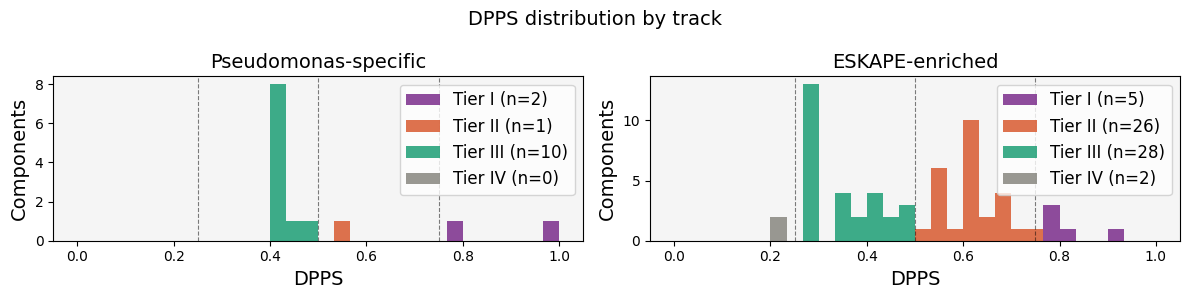

Saved: dpps_distribution_both_tracks.pdf


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
for ax, comp_scored, title in zip(
        axes,
        [comp_ps_scored, comp_es_scored],
        [f'{GENUS}-specific', 'ESKAPE-enriched']):
    bins = np.linspace(0, 1, 31)
    for tier, color in TIER_COLORS.items():
        subset = comp_scored.loc[comp_scored['tier'] == tier, 'DPPS']
        ax.hist(subset, bins=bins, color=color, alpha=0.85,
                label=f'Tier {tier} (n={len(subset)})')
    for b in TIER_BINS[1:-1]:
        ax.axvline(b, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.set_xlabel('DPPS', fontsize=14)
    ax.set_ylabel('Components', fontsize=14)
    ax.set_title(title, fontsize=14)
    ax.legend(fontsize=12)
    ax.set_facecolor('#F5F5F5')
fig.suptitle('DPPS distribution by track', fontsize=14)
fig.tight_layout()
plt.savefig('./dpps_distribution_both_tracks.pdf', bbox_inches='tight', dpi=300)
plt.show()
print('Saved: dpps_distribution_both_tracks.pdf')

### 9.2 Species proportion vs DPPS coloured by strain fraction

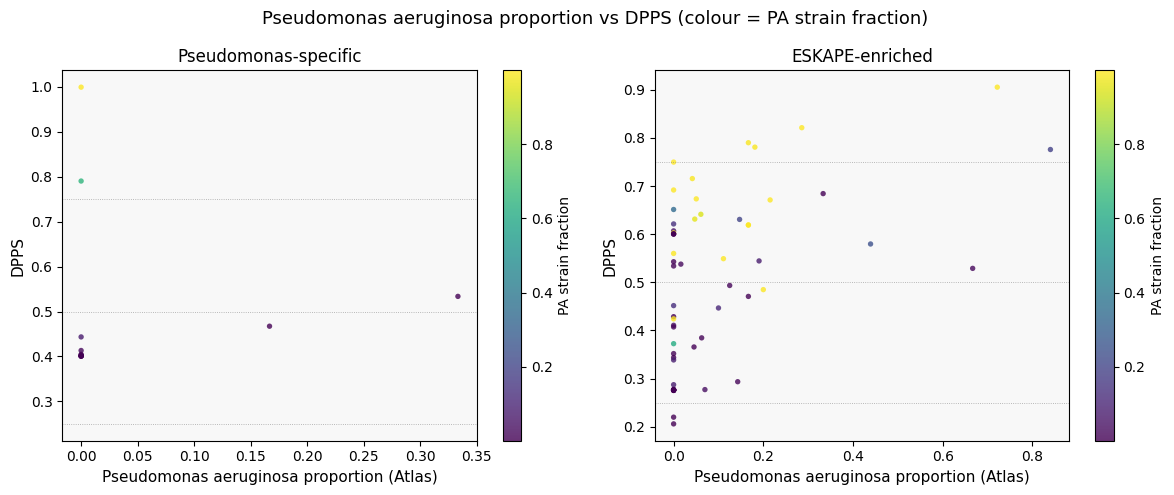

Saved: dpps_pa_proportion_scatter.pdf


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, comp_scored, title in zip(
        axes,
        [comp_ps_scored, comp_es_scored],
        [f'{GENUS}-specific', 'ESKAPE-enriched']):
    scatter = ax.scatter(
        comp_scored[SPECIES_COL],
        comp_scored['DPPS'],
        c=comp_scored['PA_strain_fraction'],
        cmap='viridis', s=15, alpha=0.8, linewidths=0
    )
    for b in TIER_BINS[1:-1]:
        ax.axhline(b, color='gray', linewidth=0.6, linestyle=':', alpha=0.7)
    plt.colorbar(scatter, ax=ax, label=f'{SPECIES_ABBR} strain fraction')
    ax.set_xlabel(f'{SPECIES} proportion (Atlas)', fontsize=11)
    ax.set_ylabel('DPPS', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.set_facecolor('#F8F8F8')
fig.suptitle(f'{SPECIES} proportion vs DPPS (colour = {SPECIES_ABBR} strain fraction)', fontsize=13)
fig.tight_layout()
plt.savefig('./dpps_pa_proportion_scatter.pdf', bbox_inches='tight', dpi=300)
plt.show()
print('Saved: dpps_pa_proportion_scatter.pdf')

### 9.3 Sub-score heatmap — top 30 Tier I per track

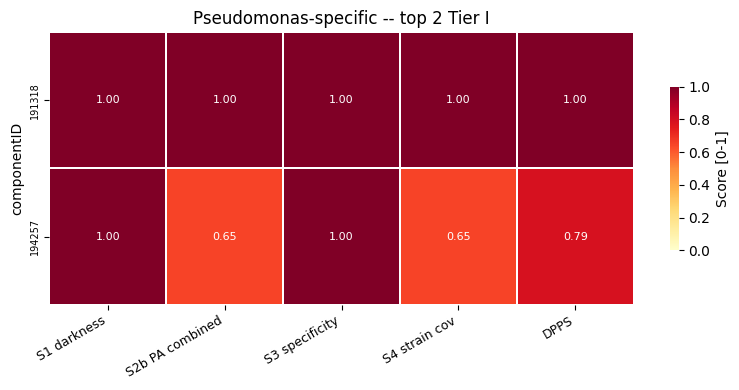

Saved: ./dpps_heatmap_pseudomonas_specific.pdf


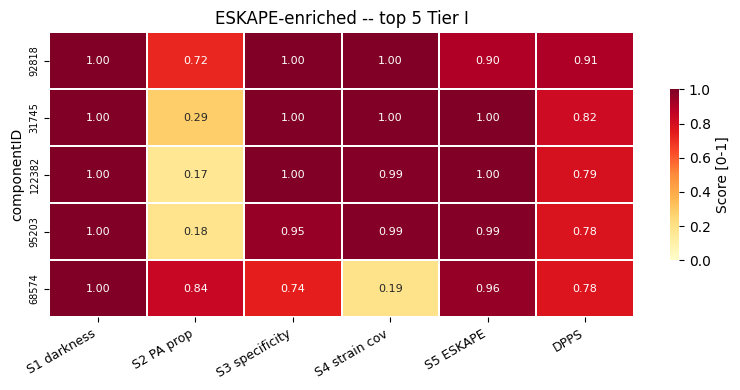

Saved: ./dpps_heatmap_eskape_enriched.pdf


In [13]:
def score_heatmap(comp_scored, score_cols, xlabels, title, fname):
    top = comp_scored[comp_scored['tier'] == 'I'].head(30)
    if len(top) == 0:
        top = comp_scored.head(30)
        print(f'No Tier I found -- showing top 30 overall for {title}')
    # Keep only columns that actually exist
    score_cols = [c for c in score_cols if c in top.columns]
    data = top.set_index('componentID')[score_cols]
    fig, ax = plt.subplots(figsize=(8, max(4, len(top) * 0.30)))
    sns.heatmap(data, ax=ax, cmap='YlOrRd', vmin=0, vmax=1,
                annot=True, fmt='.2f', annot_kws={'size': 8},
                linewidths=0.3, linecolor='white',
                cbar_kws={'label': 'Score [0-1]', 'shrink': 0.6})
    ax.set_title(f'{title} -- top {len(top)} Tier I', fontsize=12)
    ax.set_xticklabels(xlabels[:len(score_cols)], rotation=30, ha='right', fontsize=9)
    ax.tick_params(axis='y', labelsize=7)
    fig.tight_layout()
    plt.savefig(fname, bbox_inches='tight', dpi=300)
    plt.show()
    print(f'Saved: {fname}')

score_heatmap(
    comp_ps_scored,
    ['S1_darkness', 'S2b_pa_combined', 'S3_specificity', 'S4_pa_strain_coverage', 'DPPS'],
    ['S1 darkness', f'S2b {SPECIES_ABBR} combined', 'S3 specificity', 'S4 strain cov', 'DPPS'],
    f'{GENUS}-specific',
    './dpps_heatmap_pseudomonas_specific.pdf'
)

score_heatmap(
    comp_es_scored,
    ['S1_darkness', 'S2_pa_proportion', 'S3_specificity', 'S4_pa_strain_coverage', 'S5_eskape_enrich', 'DPPS'],
    ['S1 darkness', f'S2 {SPECIES_ABBR} prop', 'S3 specificity', 'S4 strain cov', 'S5 ESKAPE', 'DPPS'],
    'ESKAPE-enriched',
    './dpps_heatmap_eskape_enriched.pdf'
)


### 9.4 Cluster size distribution

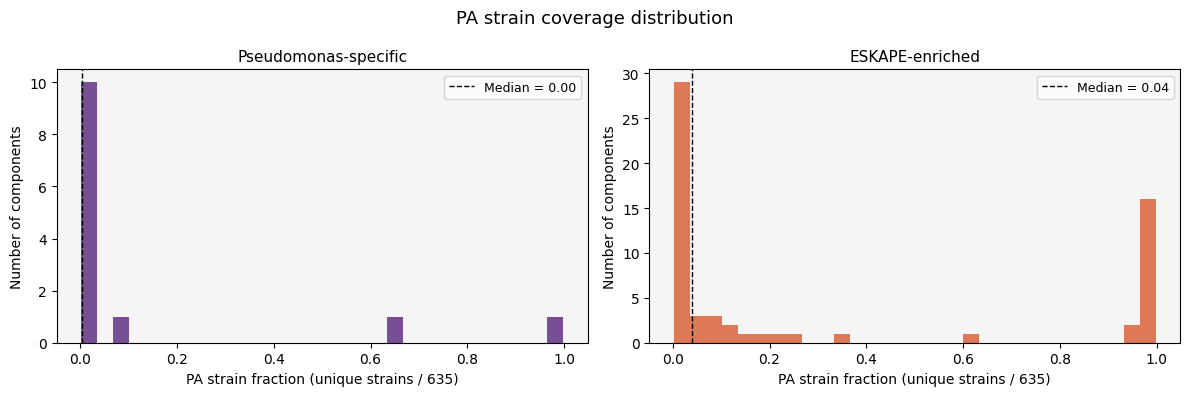

Saved: pa_strain_coverage_distribution.pdf


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, comp_scored, title, color in zip(
        axes,
        [comp_ps_scored, comp_es_scored],
        [f'{GENUS}-specific', 'ESKAPE-enriched'],
        ['#57257F', '#D85A30']):
    ax.hist(comp_scored['PA_strain_fraction'], bins=30,
            color=color, alpha=0.8, edgecolor='none')
    median_sf = comp_scored['PA_strain_fraction'].median()
    ax.axvline(median_sf, color='black', linewidth=1, linestyle='--',
               label=f'Median = {median_sf:.2f}')
    ax.set_xlabel(f'{SPECIES_ABBR} strain fraction (unique strains / {N_STRAINS})', fontsize=10)
    ax.set_ylabel('Number of components', fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9)
    ax.set_facecolor('#F5F5F5')
fig.suptitle(f'{SPECIES_ABBR} strain coverage distribution', fontsize=13)
fig.tight_layout()
plt.savefig('./pa_strain_coverage_distribution.pdf', bbox_inches='tight', dpi=300)
plt.show()
print('Saved: pa_strain_coverage_distribution.pdf')

---
## 10. Summary report

In [15]:
print('=' * 65)
print('ECLIPSE Part III -- Summary')
print('=' * 65)

for track, df_raw, df_filt, comp_s, reps_s in [
    (f'{GENUS}-specific', df_ps, df_ps_filt, comp_ps_scored, reps_ps_scored),
    ('ESKAPE-enriched',      df_es, df_es_filt, comp_es_scored, reps_es_scored),
]:
    print(f'\n--- {track} ---')
    print(f'  Input from Part II:    {len(df_raw):,} proteins, '
          f'{df_raw["componentID"].nunique():,} components')
    print(f'  After length filter:   {len(df_filt):,} proteins, '
          f'{df_filt["componentID"].nunique():,} components')
    print(f'  After clustering:      {len(reps_s):,} representatives')
    for tier in ['I', 'II', 'III', 'IV']:
        n = int((comp_s['tier'] == tier).sum())
        m = comp_s.loc[comp_s['tier'] == tier, 'DPPS'].mean()
        print(f'  Tier {tier}: {n:>4,} components  mean DPPS = {m:.3f}')

print()
print(f'Top 5 -- {GENUS}-specific:')
ps_cols = ['componentID', 'DPPS', 'tier', 'S2b_pa_combined',
           'S3_specificity', 'S4_pa_strain_coverage', 'PA_strain_count',
           SPECIES_COL]
ps_cols = [c for c in ps_cols if c in comp_ps_scored.columns]
print(comp_ps_scored[ps_cols].head(5).round(3).to_string(index=False))

print()
print('Top 5 -- ESKAPE-enriched:')
es_cols = ['componentID', 'DPPS', 'tier', 'S2_pa_proportion', 'S5_eskape_enrich',
           'S4_pa_strain_coverage', 'PA_strain_count', SPECIES_COL]
es_cols = [c for c in es_cols if c in comp_es_scored.columns]
print(comp_es_scored[es_cols].head(5).round(3).to_string(index=False))


ECLIPSE Part III -- Summary

--- Pseudomonas-specific ---
  Input from Part II:    13,230 proteins, 83 components
  After length filter:   1,471 proteins, 13 components
  After clustering:      20 representatives
  Tier I:    2 components  mean DPPS = 0.895
  Tier II:    1 components  mean DPPS = 0.534
  Tier III:   10 components  mean DPPS = 0.414
  Tier IV:    0 components  mean DPPS = nan

--- ESKAPE-enriched ---
  Input from Part II:    39,452 proteins, 215 components
  After length filter:   15,078 proteins, 61 components
  After clustering:      102 representatives
  Tier I:    5 components  mean DPPS = 0.815
  Tier II:   26 components  mean DPPS = 0.615
  Tier III:   28 components  mean DPPS = 0.350
  Tier IV:    2 components  mean DPPS = 0.213

Top 5 -- Pseudomonas-specific:
 componentID  DPPS tier  S2b_pa_combined  S3_specificity  S4_pa_strain_coverage  PA_strain_count  p_aeruginosa_proportion
      191318 0.999    I            0.998             1.0                  0.998     

In [16]:
# Inspect strain coverage for any specific component of interest.
# Works for both Format A (prefix method) and Format B (filename mapping).
# Change INSPECT_COMPONENT to any componentID you want to examine.
# Change INSPECT_TRACK to "ps" for genus-specific or "es" for ESKAPE-enriched.

INSPECT_COMPONENT = 92818   # replace with any componentID
INSPECT_TRACK     = "es"    # "ps" = genus-specific, "es" = ESKAPE-enriched

# Select the right dataframe
df_inspect_src = df_ps_filt if INSPECT_TRACK == "ps" else df_es_filt
comp_inspect = df_inspect_src[df_inspect_src["componentID"] == INSPECT_COMPONENT].copy()

if len(comp_inspect) == 0:
    print(f"Component {INSPECT_COMPONENT} not found in {INSPECT_TRACK} track after length filter.")
    print("Try a different componentID or switch INSPECT_TRACK.")
else:
    if _fmt == "prefix":
        # Format A -- extract strain from queryID prefix (P. aeruginosa method)
        has_underscore = comp_inspect["queryID"].str.contains("_", regex=False)
        comp_inspect = comp_inspect[has_underscore].copy()
        comp_inspect["strain"] = comp_inspect["queryID"].str.split("_").str[0]
    else:
        # Format B -- join from queryID_to_strain.csv
        comp_inspect = comp_inspect.merge(_strain_map, on="queryID", how="left")

    if "strain" not in comp_inspect.columns or comp_inspect["strain"].isna().all():
        print(f"No strain information available for component {INSPECT_COMPONENT}.")
        print("For Format B: check that queryID_to_strain.csv was generated by Part I Cell 40.")
        print("For Format A: check that queryIDs contain underscore separators.")
    else:
        strain_counts = (
            comp_inspect.groupby("strain")["queryID"]
            .count()
            .sort_values(ascending=False)
        )
        print(f"Component {INSPECT_COMPONENT} ({INSPECT_TRACK} track) -- proteins per strain (top 20):")
        print(strain_counts.head(20))
        print()
        print(f"Total proteins        : {len(comp_inspect)}")
        print(f"Total unique strains  : {comp_inspect['strain'].nunique()}")
        print(f"Unmapped proteins     : {comp_inspect['strain'].isna().sum()}")
        print(f"Strain fraction (S4)  : {comp_inspect['strain'].nunique() / N_STRAINS:.3f}")


Component 92818 (es track) -- proteins per strain (top 20):
strain
A0K      2
MN180    2
MMZ73    2
MMZ75    2
MMZ76    2
MMZ77    2
MN130    2
MN178    2
MN179    2
MO979    2
MMZ71    2
MO982    2
MO986    2
MON07    2
MPAO1    2
MS088    2
MS095    2
MTX71    2
MMZ72    2
MMZ70    2
Name: queryID, dtype: int64

Total proteins        : 1261
Total unique strains  : 634
Unmapped proteins     : 0
Strain fraction (S4)  : 0.998


---
## 11. Weight sensitivity analysis — both tracks

Tier I stability scores:
  Pseudomonas-specific:
 componentID  DPPS  tier1_stability
      191318 0.999            1.000
      194257 0.790            0.776
  ESKAPE-enriched:
 componentID  DPPS  tier1_stability
       92818 0.905            1.000
       31745 0.821            0.824
      122382 0.790            0.754
       95203 0.781            0.744
       68574 0.776            0.566


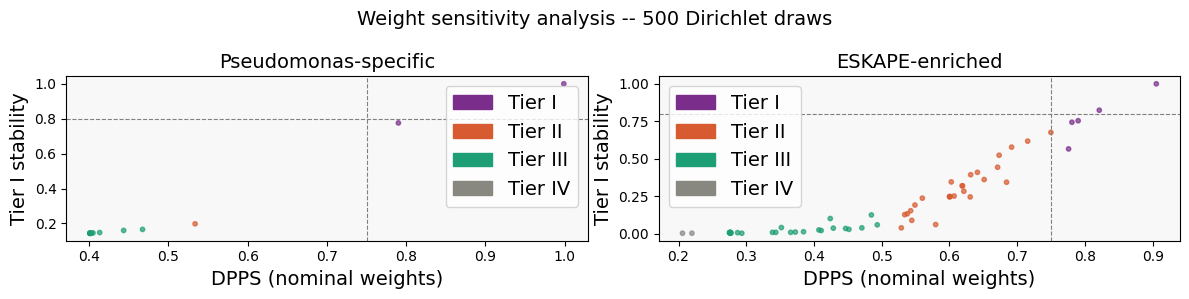

Saved: dpps_sensitivity_both_tracks.pdf


In [17]:
def sensitivity_analysis(comp_scored, weight_keys, n_boot=500):
    np.random.seed(42)
    n_scores = len(weight_keys)
    # Only use columns that exist in comp_scored
    weight_keys = [k for k in weight_keys if k in comp_scored.columns]
    score_matrix = comp_scored[weight_keys].values
    tier1_freq = np.zeros(len(comp_scored))
    for _ in range(n_boot):
        w = np.random.dirichlet(np.ones(n_scores))
        dpps_boot = np.clip(score_matrix @ w, 0, 1)
        tier1_freq += (dpps_boot >= 0.75).astype(float)
    comp_out = comp_scored.copy()
    comp_out['tier1_stability'] = tier1_freq / n_boot
    return comp_out

comp_ps_scored = sensitivity_analysis(comp_ps_scored, list(WEIGHTS_PS.keys()))
comp_es_scored = sensitivity_analysis(comp_es_scored, list(WEIGHTS_ES.keys()))

# Print stability for Tier I candidates
print('Tier I stability scores:')
for comp_s, track in [(comp_ps_scored, f'{GENUS}-specific'),
                       (comp_es_scored, 'ESKAPE-enriched')]:
    tier1 = comp_s[comp_s['tier'] == 'I'][['componentID', 'DPPS', 'tier1_stability']]
    if len(tier1) > 0:
        print(f'  {track}:')
        print(tier1.round(3).to_string(index=False))
    else:
        print(f'  {track}: no Tier I components')

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
for ax, comp_scored, title in zip(
        axes,
        [comp_ps_scored, comp_es_scored],
        [f'{GENUS}-specific', 'ESKAPE-enriched']):
    ax.scatter(comp_scored['DPPS'], comp_scored['tier1_stability'],
               c=[TIER_COLORS.get(t, 'gray') for t in comp_scored['tier']],
               s=10, alpha=0.7)
    ax.axhline(0.8, linestyle='--', color='gray', linewidth=0.8, label='80% stability')
    ax.axvline(0.75, linestyle='--', color='gray', linewidth=0.8)
    ax.set_xlabel('DPPS (nominal weights)', fontsize=14)
    ax.set_ylabel('Tier I stability', fontsize=14)
    ax.set_title(title, fontsize=14)
    patches = [mpatches.Patch(color=c, label=f'Tier {t}') for t, c in TIER_COLORS.items()]
    ax.legend(handles=patches, fontsize=14)
    ax.set_facecolor('#F8F8F8')
fig.suptitle('Weight sensitivity analysis -- 500 Dirichlet draws', fontsize=14)
fig.tight_layout()
plt.savefig('./dpps_sensitivity_both_tracks.pdf', bbox_inches='tight', dpi=300)
plt.show()
print('Saved: dpps_sensitivity_both_tracks.pdf')
